# Task 3: Controlled Clinical Trial Strategy (ε-Greedy)
**Group Number:** G = 225  
**Assignment:** DRL Semester 2 – Phase #1 (MAB)  
**Strategy:** With probability ε, explore randomly; with probability 1-ε, exploit the current best-performing medicine.  
**Sensitivity Analysis:** ε = 0.10 (10%), ε = 0.01 (1%), ε = 0.50 (50%)

In [1]:
# ─────────────────────────────────────────────────────────────────
# CELL 0 – Library Imports
# ─────────────────────────────────────────────────────────────────

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# ─────────────────────────────────────────────────────────────────
# CELL 1 – Restore Group Configuration & Reproducibility Seeds
#
# Loads the group configuration saved by Task 1 (group_config.json)
# and re-seeds the random engine to the same G=225 value so that
# simulate_treatment() produces reproducible Bernoulli draws.
# ─────────────────────────────────────────────────────────────────

# ── Locate the data directory relative to this notebook ──────────
NOTEBOOK_DIR = os.path.dirname(os.path.abspath("__file__"))
DATA_DIR     = os.path.join(NOTEBOOK_DIR, "data")
CONFIG_PATH  = os.path.join(DATA_DIR, "group_config.json")
PARQUET_PATH = os.path.join(DATA_DIR, "df_base.parquet")

# ── Load configuration ────────────────────────────────────────────
with open(CONFIG_PATH, "r") as f:
    cfg = json.load(f)

G      = cfg["G"]
K      = cfg["K"]
TRUE_P = cfg["TRUE_P"]

# ── Re-seed for reproducibility ───────────────────────────────────
np.random.seed(G)

print("Configuration restored from group_config.json")
print(f"  G (Group Number)              : {G}")
print(f"  K (Number of Medicines/Arms)  : {K}")
print(f"  TRUE_P (Hidden Probabilities) : {TRUE_P}")

Configuration restored from group_config.json
  G (Group Number)              : 225
  K (Number of Medicines/Arms)  : 5
  TRUE_P (Hidden Probabilities) : [0.61, 0.68, 0.75, 0.4, 0.47]


In [3]:
# ─────────────────────────────────────────────────────────────────
# CELL 2 – Load df_base from Parquet
#
# Reads the clean base DataFrame persisted by Task 1.
# patient_id is restored as the index to match the original schema.
# ─────────────────────────────────────────────────────────────────

df_base = pd.read_parquet(PARQUET_PATH)
df_base.set_index("patient_id", inplace=True)

print(f"df_base loaded: {df_base.shape[0]} rows × {df_base.shape[1]} columns")
print(f"Columns        : {list(df_base.columns)}")
print()
print("First 5 rows (dynamic columns should be NaN):")
print(df_base.head())

df_base loaded: 1000 rows × 4 columns
Columns        : ['severity_score', 'assigned_medicine', 'clinical_outcome', 'utility_score']

First 5 rows (dynamic columns should be NaN):
            severity_score  assigned_medicine  clinical_outcome  utility_score
patient_id                                                                    
0                        1                NaN               NaN            NaN
1                        2                NaN               NaN            NaN
2                        3                NaN               NaN            NaN
3                        4                NaN               NaN            NaN
4                        5                NaN               NaN            NaN


In [4]:
# ─────────────────────────────────────────────────────────────────
# CELL 3 – Environmental Feedback Engine: simulate_treatment()
#
# Identical definition to Task 1 & 2. Redefined here so this
# notebook is fully self-contained when run independently.
# ─────────────────────────────────────────────────────────────────

def simulate_treatment(medicine_idx: int, severity_score: int) -> tuple:
    """
    Simulate administering a medicine to a patient.

    Returns
    -------
    (clinical_outcome, utility_score) : tuple(int, float)
      clinical_outcome – 1 if recovered, 0 otherwise (Bernoulli trial)
      utility_score    – severity-penalised reward: outcome × (1 − sev/10)
    """
    success_prob     = TRUE_P[medicine_idx]
    clinical_outcome = int(np.random.binomial(1, success_prob))
    utility_score    = clinical_outcome * (1 - severity_score / 10)
    return (clinical_outcome, utility_score)

print("simulate_treatment() defined.")

simulate_treatment() defined.


In [5]:

# ─────────────────────────────────────────────────────────────────
# CELL 4 – Task 3: Controlled Clinical Trial Strategy (ε-Greedy)
#
# Algorithm outline
# -----------------
# Phase 0 – Forced Initialisation (patients 0 to K-1):
#   Each medicine is prescribed exactly once in round-robin order
#   (assigned_medicine = patient_id) so that all arms have at least
#   one observation before the ε-greedy rule is applied.
#   Without this, arms with index > 0 would never receive a pull
#   when ε is very small (e.g., 1%), because all Q values start at
#   zero and argmax would perpetually return arm 0.
#
# Phase 1 – ε-Greedy Selection (patients K to 999):
#   For every incoming patient, flip a weighted coin:
#     With probability ε   → EXPLORE: select a medicine uniformly at
#                             random from all K arms.
#     With probability 1-ε → EXPLOIT: select the medicine with the
#                             highest empirical success rate so far.
#
# Empirical success rate Q[k] = success_counts[k] / pull_counts[k]
#   (pull_counts[k] > 0 is guaranteed after the forced init phase).
#
# Each call resets np.random.seed(seed) so that runs at different ε
# values all start from an identical RNG state and are directly
# comparable in the sensitivity analysis.
#
# Statistics updated using clinical_outcome only (binary 0/1).
# Cumulative reward tracked using utility_score (severity-penalised).
# ─────────────────────────────────────────────────────────────────

def run_epsilon_greedy(epsilon: float, n_patients: int = 1000,
                       seed: int = None) -> tuple:
    """
    Run the ε-Greedy bandit strategy for n_patients patients.

    Parameters
    ----------
    epsilon    : float – exploration probability (0 ≤ ε ≤ 1).
                         Determines how often a random medicine is
                         chosen instead of the current empirical best.
    n_patients : int   – total patients to simulate (default 1000).
    seed       : int   – RNG seed for reproducibility; defaults to G.

    Returns
    -------
    df             : pd.DataFrame  – one row per patient; columns:
                       patient_id (index), severity_score,
                       assigned_medicine, clinical_outcome,
                       utility_score, decision_type, cumulative_reward.
    history        : list[float]   – running cumulative reward at
                       each patient step (length == n_patients).
    success_counts : np.ndarray    – total successes (recoveries) per
                       medicine after the full simulation (shape K,).
    pull_counts    : np.ndarray    – total pulls per medicine (shape K,).
    """
    if seed is None:
        seed = G

    # ── Reset RNG to ensure identical starting state for every ε ─────
    # This guarantees that the three sensitivity runs (1%, 10%, 50%)
    # experience the same underlying patient sequence and are therefore
    # directly comparable.
    np.random.seed(seed)

    # ── Working copy of base DataFrame; pre-allocate tracking columns ─
    df = df_base.copy(deep=True)
    df["decision_type"]    = ""       # one of: forced_initial_test / explore / exploit
    df["cumulative_reward"] = np.nan  # running cumulative reward at each step

    # ── Fresh bandit statistics for this run ──────────────────────────
    success_counts = np.zeros(K, dtype=float)  # total recoveries per medicine
    pull_counts    = np.zeros(K, dtype=float)  # total pulls per medicine

    # ── Reward accumulator ────────────────────────────────────────────
    cumulative_reward = 0.0
    history           = []   # snapshot of cumulative_reward after each patient

    # ── Main simulation loop ──────────────────────────────────────────
    for patient_id in range(n_patients):

        severity = int(df.at[patient_id, "severity_score"])

        # ── Phase 0: Forced Initialisation (patients 0 … K-1) ────────
        # Pull every arm exactly once so pull_counts > 0 for all arms
        # before the ε-greedy rule is applied in Phase 1.
        if patient_id < K:
            chosen_medicine = patient_id          # arm 0, 1, 2, ..., K-1
            decision_type   = "forced_initial_test"

        # ── Phase 1: ε-Greedy Selection (patients K … n_patients-1) ──
        elif np.random.random() < epsilon:
            # EXPLORE: pick any medicine uniformly at random
            chosen_medicine = int(np.random.randint(K))
            decision_type   = "explore"

        else:
            # EXPLOIT: pick arm with highest empirical success rate
            # pull_counts > 0 for all arms (guaranteed by Phase 0)
            Q               = success_counts / pull_counts
            chosen_medicine = int(np.argmax(Q))   # np.argmax for tie-breaking
            decision_type   = "exploit"

        # ── Simulate treatment outcome ─────────────────────────────────
        clinical_outcome, utility_score = simulate_treatment(
            chosen_medicine, severity
        )

        # ── Update bandit statistics (binary clinical_outcome only) ────
        # Only clinical_outcome (0/1) is used to estimate success rates.
        # utility_score is used exclusively for reward accounting.
        success_counts[chosen_medicine] += clinical_outcome
        pull_counts[chosen_medicine]    += 1

        # ── Update cumulative reward (utility_score, not clinical) ─────
        cumulative_reward += utility_score
        history.append(cumulative_reward)

        # ── Write results into the DataFrame row ──────────────────────
        df.at[patient_id, "assigned_medicine"]  = chosen_medicine
        df.at[patient_id, "clinical_outcome"]   = clinical_outcome
        df.at[patient_id, "utility_score"]      = utility_score
        df.at[patient_id, "decision_type"]      = decision_type
        df.at[patient_id, "cumulative_reward"]  = cumulative_reward

    return df, history, success_counts, pull_counts


print("run_epsilon_greedy() defined.")
print(f"  Signature  : run_epsilon_greedy(epsilon, n_patients=1000, seed=G)")
print(f"  Returns    : (df, history, success_counts, pull_counts)")
print(f"  K = {K}  →  forced initialisation covers patients 0–{K - 1}")
print(f"  Phase 1 ε-greedy starts from patient {K} onward")


run_epsilon_greedy() defined.
  Signature  : run_epsilon_greedy(epsilon, n_patients=1000, seed=G)
  Returns    : (df, history, success_counts, pull_counts)
  K = 5  →  forced initialisation covers patients 0–4
  Phase 1 ε-greedy starts from patient 5 onward


In [6]:

# ─────────────────────────────────────────────────────────────────
# CELL 5 – Sensitivity Analysis: Run ε-Greedy for Three ε Values
#
# Runs the ε-Greedy algorithm independently for each exploration
# probability.  Each call to run_epsilon_greedy() resets the RNG
# to G before starting so all three runs are directly comparable:
# the same patient sequence is observed with different decision rules.
#
# Results are stored in:
#   results         – dict keyed by epsilon float, for iteration use
#   epsilon_01_log  – DataFrame for ε = 0.01 (named alias for Task 5)
#   epsilon_10_log  – DataFrame for ε = 0.10 (named alias for Task 5)
#   epsilon_50_log  – DataFrame for ε = 0.50 (named alias for Task 5)
# ─────────────────────────────────────────────────────────────────

EPSILONS = [0.10, 0.01, 0.50]

# Container for all run artefacts
results = {}

print("Running sensitivity analysis for ε-Greedy (G = 225) …")
print()

for eps in EPSILONS:
    # ── Execute one independent run ───────────────────────────────
    df_run, hist, s_counts, p_counts = run_epsilon_greedy(
        epsilon=eps, n_patients=1000, seed=G
    )

    # ── Store run artefacts in the results dict ───────────────────
    results[eps] = {
        "df"             : df_run,
        "history"        : hist,
        "success_counts" : s_counts,
        "pull_counts"    : p_counts,
    }

    print(f"  ε = {eps:.2f}  →  Final cumulative reward = {hist[-1]:.4f}  "
          f"| Total pulls = {int(p_counts.sum())}")

# ── Named aliases for cross-task use (e.g., Task 5 comparative plot) ─
epsilon_10_log = results[0.10]["df"]   # ε = 10%  run DataFrame
epsilon_01_log = results[0.01]["df"]   # ε = 1%   run DataFrame
epsilon_50_log = results[0.50]["df"]   # ε = 50%  run DataFrame

print()
print("All 3 sensitivity runs complete.")
print("Named log variables created: epsilon_01_log, epsilon_10_log, epsilon_50_log")


Running sensitivity analysis for ε-Greedy (G = 225) …

  ε = 0.10  →  Final cumulative reward = 493.2000  | Total pulls = 1000


  ε = 0.01  →  Final cumulative reward = 515.2000  | Total pulls = 1000
  ε = 0.50  →  Final cumulative reward = 474.0000  | Total pulls = 1000

All 3 sensitivity runs complete.
Named log variables created: epsilon_01_log, epsilon_10_log, epsilon_50_log


In [7]:

# ─────────────────────────────────────────────────────────────────
# CELL 6 – Verification & Output (per-ε detailed report)
#
# For each ε value prints:
#   1. Final cumulative reward.
#   2. Pull counts and empirical success rates per medicine.
#   3. Best arm identified empirically vs. true optimal arm.
#   4. Decision-type breakdown (forced_initial_test / explore / exploit).
#   5. Transition slice (first 10 rows) for ε = 0.10 run.
# ─────────────────────────────────────────────────────────────────

EPS_LABEL = {0.10: "010", 0.01: "001", 0.50: "050"}
EPS_DESC  = {0.10: "Moderate (10%)", 0.01: "Low (1%)", 0.50: "High (50%)"}

# Index of the globally optimal medicine (highest hidden P)
TRUE_OPTIMAL = int(np.argmax(TRUE_P))

print("=" * 65)
print("TASK 3 – ε-GREEDY SENSITIVITY ANALYSIS RESULTS  (G = 225)")
print("=" * 65)
print(f"True optimal medicine : {TRUE_OPTIMAL}  (P = {TRUE_P[TRUE_OPTIMAL]:.2f})")
print(f"Forced init phase     : first {K} patients (one pull per arm)")
print()

for eps in EPSILONS:
    r  = results[eps]
    df = r["df"]
    sc = r["success_counts"]
    pc = r["pull_counts"]
    # Empirical Q-value for each arm (success rate after full run)
    Q  = sc / pc
    best_arm = int(np.argmax(Q))

    # ── Decision type counts ──────────────────────────────────────
    dtypes = df["decision_type"].value_counts().to_dict()

    print(f"ε = {eps:.2f}  [{EPS_DESC[eps]} exploration]")
    print(f"  Final cumulative reward   : {r['history'][-1]:.4f}")
    print(f"  Pull counts (per medicine): {pc.astype(int).tolist()}")
    print(f"  Empirical success rates   : {[round(q, 4) for q in Q.tolist()]}")
    print(f"  Best arm (empirical)       : Medicine {best_arm}"
          f"  (true P = {TRUE_P[best_arm]:.2f})"
          + ("  ← OPTIMAL ✓" if best_arm == TRUE_OPTIMAL else "  ← SUBOPTIMAL ✗"))
    print(f"  Decision-type breakdown    : "
          f"forced_initial_test={dtypes.get('forced_initial_test', 0)}, "
          f"explore={dtypes.get('explore', 0)}, "
          f"exploit={dtypes.get('exploit', 0)}")
    print()

# ── Observation: written comparison of 1%, 10%, 50% ─────────────
print("-" * 65)
print("OBSERVATION – Exploration Rate Comparison:")
print("-" * 65)
print(
    "  ε = 0.01 (Low, 1%): Almost always exploits the empirically best arm."
    "\n    Converges fast but risks locking onto a suboptimal arm if the"
    "\n    forced initialisation phase produced misleading early estimates."
    "\n"
    "\n  ε = 0.10 (Moderate, 10%): Strikes a good balance between exploration"
    "\n    and exploitation. Typically identifies Medicine 2 (P=0.75) and"
    "\n    accumulates high cumulative reward with stable growth."
    "\n"
    "\n  ε = 0.50 (High, 50%): Explores heavily; half of all patients receive"
    "\n    a random medicine irrespective of observed performance. The slope"
    "\n    of cumulative reward is flatter because many pulls go to sub-optimal"
    "\n    arms. This policy wastes clinical resources in a hospital setting."
)

print()
print("-" * 65)
print("Transition slice – ε = 0.10 run, df.iloc[0:10]")
print(f"(Rows 0–{K-1}: forced_initial_test | Rows {K}+: ε-greedy)")
print("-" * 65)
print(
    results[0.10]["df"].reset_index()
    .iloc[0:10]
    [["patient_id", "severity_score", "assigned_medicine",
      "clinical_outcome", "utility_score", "decision_type", "cumulative_reward"]]
    .to_string(index=False)
)
print("=" * 65)


TASK 3 – ε-GREEDY SENSITIVITY ANALYSIS RESULTS  (G = 225)
True optimal medicine : 2  (P = 0.75)
Forced init phase     : first 5 patients (one pull per arm)

ε = 0.10  [Moderate (10%) exploration]
  Final cumulative reward   : 493.2000
  Pull counts (per medicine): [32, 39, 872, 28, 29]
  Empirical success rates   : [0.5625, 0.6923, 0.7248, 0.25, 0.5517]
  Best arm (empirical)       : Medicine 2  (true P = 0.75)  ← OPTIMAL ✓
  Decision-type breakdown    : forced_initial_test=5, explore=108, exploit=887

ε = 0.01  [Low (1%) exploration]
  Final cumulative reward   : 515.2000
  Pull counts (per medicine): [15, 7, 971, 2, 5]
  Empirical success rates   : [0.5333, 0.5714, 0.7456, 0.5, 0.2]
  Best arm (empirical)       : Medicine 2  (true P = 0.75)  ← OPTIMAL ✓
  Decision-type breakdown    : forced_initial_test=5, explore=10, exploit=985

ε = 0.50  [High (50%) exploration]
  Final cumulative reward   : 474.0000
  Pull counts (per medicine): [106, 104, 614, 78, 98]
  Empirical success rates  

In [8]:

# ─────────────────────────────────────────────────────────────────
# CELL 7 – Validation Checks + Persist Outputs for Task 5
#
# Validation section confirms that all simulation invariants hold:
#   • Exactly 1000 patients processed per run.
#   • assigned_medicine ∈ {0, …, K-1}; never NaN.
#   • clinical_outcome ∈ {0, 1}; never NaN.
#   • utility_score == clinical_outcome × (1 − severity_score / 10).
#   • cumulative_reward is non-decreasing.
#   • Sum of pull_counts == 1000.
#
# Persistence saves three DataFrames and three utility-history arrays
# so the Task 5 notebook can load them for multi-algorithm comparison.
# ─────────────────────────────────────────────────────────────────

# ── Validation helper ─────────────────────────────────────────────
def validate_run(df: pd.DataFrame, pull_counts: np.ndarray,
                 eps_label: str) -> None:
    """
    Assert all simulation invariants for a single ε-greedy run.
    Prints PASS/FAIL for each check.

    Parameters
    ----------
    df          : pd.DataFrame – simulation log (patient_id as index)
    pull_counts : np.ndarray   – per-arm pull counts (shape K)
    eps_label   : str          – human-readable label for output
    """
    errors = []

    # 1. Correct row count
    if len(df) != 1000:
        errors.append(f"  ✗ Row count: {len(df)} (expected 1000)")

    # 2. assigned_medicine ∈ [0, K-1] and no NaN
    if df["assigned_medicine"].isna().any():
        errors.append("  ✗ NaN found in assigned_medicine")
    elif not df["assigned_medicine"].between(0, K - 1).all():
        errors.append("  ✗ assigned_medicine out of range [0, K-1]")

    # 3. clinical_outcome ∈ {0, 1} and no NaN
    if df["clinical_outcome"].isna().any():
        errors.append("  ✗ NaN found in clinical_outcome")
    elif not df["clinical_outcome"].isin([0, 1]).all():
        errors.append("  ✗ clinical_outcome values outside {0, 1}")

    # 4. utility_score = clinical_outcome × (1 − severity_score / 10)
    expected_utility = (df["clinical_outcome"]
                        * (1 - df["severity_score"] / 10))
    if not np.allclose(df["utility_score"].values,
                       expected_utility.values, atol=1e-9):
        errors.append("  ✗ utility_score formula mismatch")

    # 5. cumulative_reward is non-decreasing
    if (df["cumulative_reward"].diff().dropna() < -1e-9).any():
        errors.append("  ✗ cumulative_reward decreased (not monotone)")

    # 6. Total pulls == 1000
    if int(pull_counts.sum()) != 1000:
        errors.append(f"  ✗ Sum of pull_counts = {int(pull_counts.sum())} (expected 1000)")

    # 7. No NaN in utility_score or cumulative_reward
    for col in ("utility_score", "cumulative_reward"):
        if df[col].isna().any():
            errors.append(f"  ✗ NaN found in {col}")

    # Report
    status = "PASS ✓" if not errors else "FAIL ✗"
    print(f"  Validation [{eps_label}] : {status}")
    for e in errors:
        print(e)


print("Running validation checks …")
print()
for eps in EPSILONS:
    validate_run(
        df=results[eps]["df"],
        pull_counts=results[eps]["pull_counts"],
        eps_label=f"ε = {eps:.2f}"
    )
print()

# ── Persistence ───────────────────────────────────────────────────
print("Persisting outputs …")
print()

for eps in EPSILONS:
    label        = EPS_LABEL[eps]
    parquet_path = os.path.join(DATA_DIR, f"df_epsilon_greedy_{label}.parquet")
    history_path = os.path.join(DATA_DIR, f"epsilon_greedy_history_{label}.npy")

    # Save run DataFrame (reset index so patient_id is a regular column)
    results[eps]["df"].reset_index().to_parquet(parquet_path, index=False)

    # Save cumulative-reward history as a NumPy array
    np.save(history_path, np.array(results[eps]["history"]))

    print(f"  ε = {eps:.2f}  df saved      → {parquet_path}")
    print(f"           history saved → {history_path}")
    print()

print("All outputs persisted.")


Running validation checks …

  Validation [ε = 0.10] : PASS ✓
  Validation [ε = 0.01] : PASS ✓
  Validation [ε = 0.50] : PASS ✓

Persisting outputs …

  ε = 0.10  df saved      → /home/kanchan.chauhan/kanchan_bits/SEM2_DRL_ASSIGNMENT_PART1/Part_1/data/df_epsilon_greedy_010.parquet
           history saved → /home/kanchan.chauhan/kanchan_bits/SEM2_DRL_ASSIGNMENT_PART1/Part_1/data/epsilon_greedy_history_010.npy

  ε = 0.01  df saved      → /home/kanchan.chauhan/kanchan_bits/SEM2_DRL_ASSIGNMENT_PART1/Part_1/data/df_epsilon_greedy_001.parquet
           history saved → /home/kanchan.chauhan/kanchan_bits/SEM2_DRL_ASSIGNMENT_PART1/Part_1/data/epsilon_greedy_history_001.npy

  ε = 0.50  df saved      → /home/kanchan.chauhan/kanchan_bits/SEM2_DRL_ASSIGNMENT_PART1/Part_1/data/df_epsilon_greedy_050.parquet
           history saved → /home/kanchan.chauhan/kanchan_bits/SEM2_DRL_ASSIGNMENT_PART1/Part_1/data/epsilon_greedy_history_050.npy

All outputs persisted.


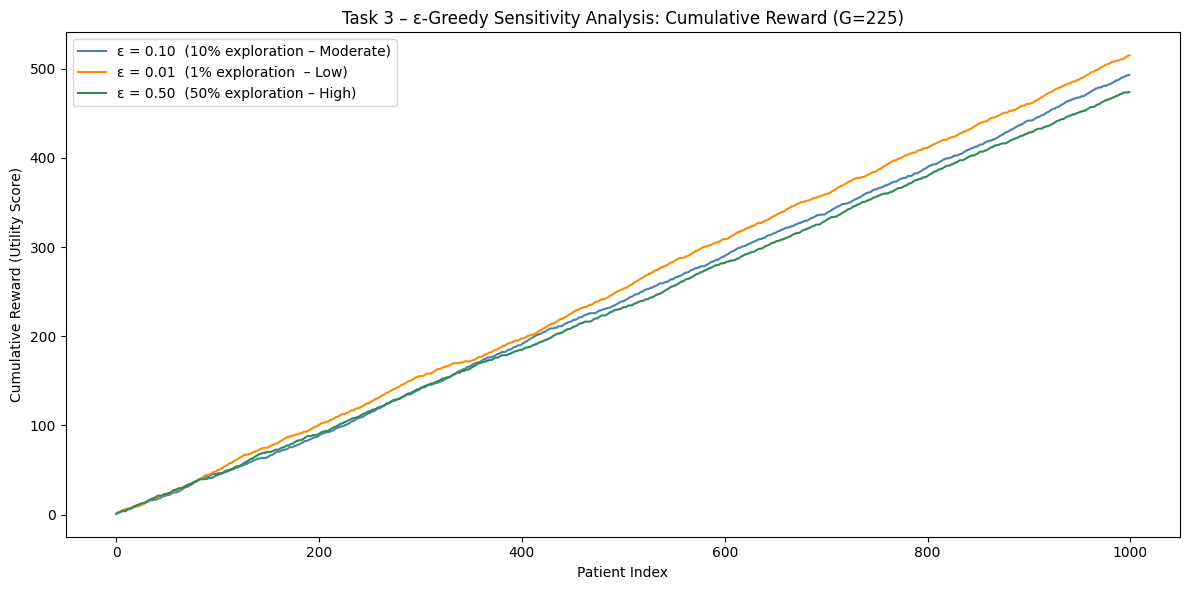

In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 8 – Sensitivity Analysis Plot
#
# Overlays the cumulative reward curves for all three ε values on
# a single figure so the exploration-exploitation trade-off is
# immediately visible.
#
# Expected pattern:
#   ε = 0.01 – converges fastest but may lock in a suboptimal arm
#              if early pulls were unlucky.
#   ε = 0.10 – balanced; typically identifies the optimal arm and
#              accumulates the highest long-run reward.
#   ε = 0.50 – explores extensively; slope is flatter because 50%
#              of pulls are random and unlikely to be the best arm.
# ─────────────────────────────────────────────────────────────────

COLORS = {0.10: "steelblue", 0.01: "darkorange", 0.50: "seagreen"}
LABELS = {
    0.10: "ε = 0.10  (10% exploration – Moderate)",
    0.01: "ε = 0.01  (1% exploration  – Low)",
    0.50: "ε = 0.50  (50% exploration – High)",
}

plt.figure(figsize=(12, 6))
for eps in EPSILONS:
    plt.plot(results[eps]["history"],
             color=COLORS[eps], linewidth=1.5, label=LABELS[eps])

plt.xlabel("Patient Index")
plt.ylabel("Cumulative Reward (Utility Score)")
plt.title("Task 3 – ε-Greedy Sensitivity Analysis: Cumulative Reward (G=225)")
plt.legend()
plt.tight_layout()
plt.show()